In [31]:
import json
import os
try:
    from backend.utils import load_json
except ModuleNotFoundError:
    print("Updating working directory....")
    os.chdir("../")
    print(os.getcwd())
    from backend.utils import load_json
    
from tqdm import tqdm 
from backend.utils import load_response_dict
from backend.nli_labels import ExNLILabel
import math

import matplotlib.pyplot as plt
import numpy as np


In [3]:
from backend.dataset_utils import organize_dataset, retrieve_annotation
test_dataset = "data/test.json"
dataset = load_json(test_dataset)
dataset = organize_dataset(dataset)

In [4]:
responses0 = load_response_dict("out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed0")
responses1 = load_response_dict("out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed1")
responses42 = load_response_dict("out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed42")

responses_by_seed = {
    0 : responses0,
    1 : responses1,
    42: responses42
}

Loading responses: 100%|██████████| 123/123 [00:11<00:00, 10.71it/s]


In [5]:
ids = list(responses0.keys())

In [6]:
def by_id(id, responses_by_seed):
    out = {}
    for k,v in responses_by_seed.items():
        out[k] = v[id]
    return out

In [ ]:
def find_relevant_tokens(logprobs, key_phrase):
    cleaned_key_phrase = "".join(key_phrase.split()) #remove whitespace to avoid issues
    token_buffer = ""
    token_pos = []
    # start checking from the end of the list to reduce searching time
    for i, logprob in list(reversed(list(enumerate(logprobs)))):
        buffer_log = ""
        token = logprob["token"]
        # print(token, token_buffer)
        subphrase = "".join((token + token_buffer).split())
        if subphrase in cleaned_key_phrase:
            token_pos.insert(0, i) # prepend index due to reversed nature (can also flip later) 
            token_buffer = token + token_buffer # prepend token due to reversed nature 
        elif "".join(token.split()) in cleaned_key_phrase: # token in key-phrase but not in combination with the previous ones
            token_buffer = token
            token_pos = [i]
        else:
            buffer_log += f"iter {i}: {token_buffer} | {token} \n"
            token_buffer = ""
            token_pos = []
            continue
        
        clean_token_buffer = "".join(token_buffer.split())
        if cleaned_key_phrase in clean_token_buffer:
            # print(token_buffer)
            return token_pos
    
    out_str = ""
    for lp in logprobs:
        out_str += lp["token"]
    print("==== OUTPUT STRING ====")
    print(logprobs)
    print(out_str)
    print("====   BUFFER LOG  ====")
    print(buffer_log)
    error_msg = f"Key phrase '{key_phrase}' not found in logprobs tokens!"
    raise KeyError(error_msg)

def construct_key_phrase(prediction, structured_field=None):
    if structured_field:
        return f'{structured_field}": "{prediction}' # without starting or trailing " because tokenization is weird
    else:
        return prediction
    
def phrase_from_tokens(logprobs, token_pos):
    phrase = ""
    for tp in token_pos:
        phrase += logprobs[tp]["token"]
    return phrase

In [8]:
one = by_id(1, responses_by_seed)
zero = one[0]

def find_relevant_logprobs(response, return_first=True):
    # set up stuff
    
    prediction = response["prediction"]
    structure = "classification"
    key_phrase = construct_key_phrase(prediction, structured_field=structure)
    # print("=== STAGE 1: SETUP")
    # print(f"Key Phrase: {key_phrase}")

    # find key phrase
    logprobs = response["logprobs"]
    token_pos = find_relevant_tokens(logprobs, key_phrase)
    # print(f"Positions: {token_pos}")
    # print(f"Phrase: {phrase_from_tokens(logprobs, token_pos)}")

    # find prediction phrase
    # print("=== STAGE 3: ISOLATE PREDICTION")
    key_phrase_tokens = logprobs[token_pos[0]:token_pos[-1]+1]
    # print([kpt["token"] for kpt in key_phrase_tokens])
    prediction_pos = find_relevant_tokens(key_phrase_tokens, prediction)
    # print(f"""Positions before correct: {prediction_pos}""")
    prediction_pos = [pp + token_pos[0] for pp in prediction_pos]
    # print(f"""Positions: {prediction_pos}
    if return_first:
        relevant_logprobs = [logprobs[pp] for pp in prediction_pos]
        return relevant_logprobs[0]
    else:
        return logprobs[prediction_pos[0]]

In [21]:
def logprob_to_prob(logprob, temp=1.):
    return math.exp(logprob / temp)

def get_probs(logprobs, temp=1.):
    # finds probabilities for a single token and its top logprobs
    for v in logprobs:
        # print(v)
        v["prob"] = logprob_to_prob(v["logprob"], temp=temp)
        top_logprobs = v["top_logprobs"]
        for token in top_logprobs:
            token["prob"] = logprob_to_prob(token["logprob"], temp=temp)
        # print(v["prob"])


for seed, responses in responses_by_seed.items():
    for doc_id, doc_responses in tqdm(responses.items()):
        for hypo_id, hypo_response in doc_responses["annotation_sets"][0]["annotations"].items():
            logprobs = hypo_response["logprobs"]
            get_probs(logprobs, temp=1.)
            pred_tokens = find_relevant_logprobs(hypo_response)
            hypo_response["pred_tokens"] = pred_tokens

100%|██████████| 123/123 [00:00<00:00, 316.46it/s]


100%|██████████| 123/123 [00:00<00:00, 26758.27it/s]

Num correct: 4723
Num wrong:   1550


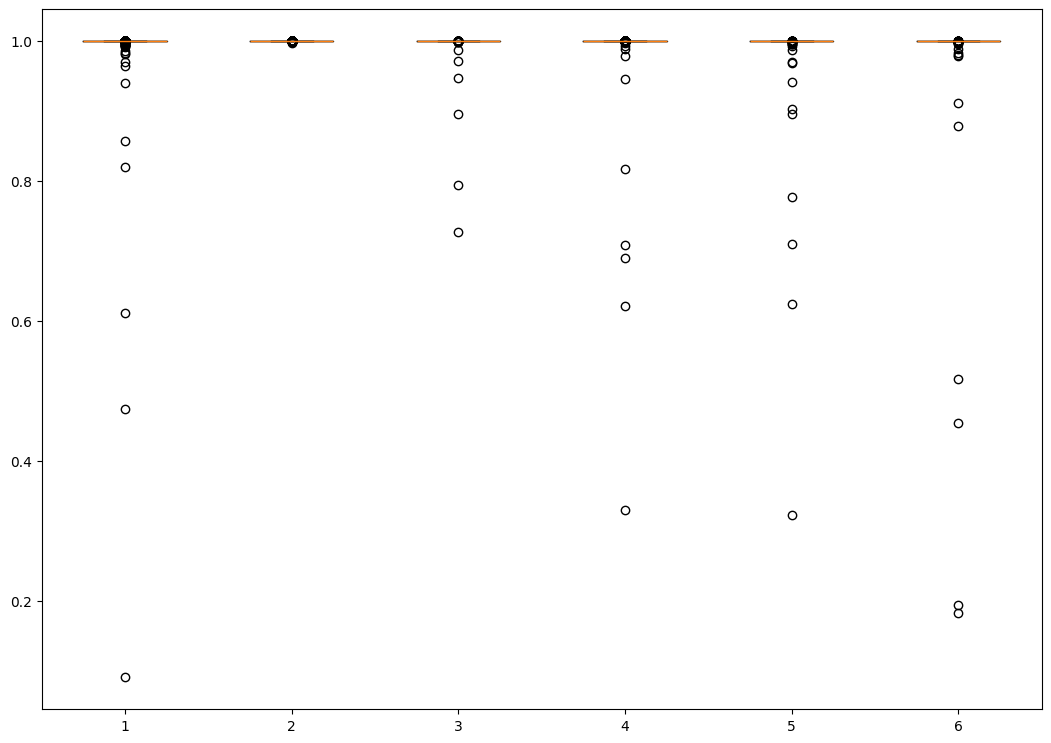

In [ ]:
correct = {}
wrong = {}

for seed, responses in (responses_by_seed.items()):
    for doc_id, doc_responses in tqdm(responses.items()):
        for hypo_id, hypo_response in doc_responses["annotation_sets"][0]["annotations"].items():
            annotation = dataset[doc_id]["annotation_sets"][0]["annotations"][hypo_id]
            gt = annotation["choice"]
            pred = hypo_response["prediction"]
            pred_token = hypo_response["pred_tokens"]["token"]
            pred_prob = hypo_response["pred_tokens"]["prob"]
            el = (pred_token, pred_prob)
            if gt == pred:
                target_dict = correct
            else:
                target_dict = wrong

            if pred_token not in target_dict.keys():
                target_dict[pred_token] = []
            target_dict[pred_token].append(pred_prob)
            
print(f"Num correct: {sum(len(v) for v in correct.values())}")
print(f"Num wrong:   {sum(len(v) for v in wrong.values())}")

d = list(correct.values()) + list(wrong.values())

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
bp = ax.boxplot(d)

plt.show()